In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import time
torch.manual_seed(42)
mse = nn.MSELoss()
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
def select_landmarks(y_pos, num_landmarks=128):
    num_landmarks = min(num_landmarks, y_pos.shape[0])
    indices = torch.randperm(y_pos.shape[0], device=y_pos.device)[:num_landmarks]
    return y_pos[indices]

def kzu(z, landmarks, T):
    return torch.exp(-torch.cdist(z, landmarks) / T)

def build_nystrom_cache(landmarks, T, jitter=1e-5):
    K_uu = kzu(landmarks, landmarks, T)
    K_uu = K_uu + jitter * torch.eye(len(landmarks), device=landmarks.device)
    eigenvalues, eigenvectors = torch.linalg.eigh(K_uu)
    eigenvalues = torch.clamp(eigenvalues, min=jitter)
    return eigenvectors @ torch.diag(torch.rsqrt(eigenvalues)) @ eigenvectors.T

def nystrom_map(z, landmarks, K_uu_inv_sqrt, T):
    # The factor is cached: no eigendecomposition occurs during training.
    return (kzu(z, landmarks, T) @ K_uu_inv_sqrt).T

def pre_compute_summaries(y_pos, landmarks, K_uu_inv_sqrt, T):
    phi_y = nystrom_map(y_pos, landmarks, K_uu_inv_sqrt, T)
    return phi_y @ y_pos, phi_y.sum(dim=1, keepdim=True)

def attraction(y_neg, landmarks, K_uu_inv_sqrt, Ap, bp, T):
    phi = nystrom_map(y_neg, landmarks, K_uu_inv_sqrt, T)
    numerator = (Ap.T @ phi).T
    denominator = phi.T @ bp + 1e-8
    return numerator / denominator


def repulsion(y_neg, T):
    N = y_neg.shape[0]
    dist_neg = torch.cdist(y_neg, y_neg)
    
    # Remove self-interaction (Line 14)
    dist_neg += torch.eye(N, device=dist_neg.device) * 1e6 
    
    K = torch.exp(-dist_neg / T)
    
    # Line 15 normalization
    denominator = K.sum(dim=1, keepdim=True) + 1e-8
    drift_neg = (K @ y_neg) / denominator
    
    return drift_neg

def compute_V(y_neg, landmarks, K_uu_inv_sqrt, Ap, bp, T=1.0):
    V_pos = attraction(y_neg, landmarks, K_uu_inv_sqrt, Ap, bp, T)
    V_neg = repulsion(y_neg, T)
    V = V_pos - V_neg
    return V

def drift_loss(generated, landmarks, K_uu_inv_sqrt, Ap, bp, T):
    with torch.no_grad():
        # y_neg is your generated batch
        V = compute_V(generated, landmarks, K_uu_inv_sqrt, Ap, bp, T)
        # Eq. (5) in the paper: regress to one full stop-gradient drift step.
        frozen_targets = (generated + V).detach()
    return mse(generated, frozen_targets), V

def recon_loss(y_pos_recon, y_pos):
    return F.mse_loss(y_pos_recon, y_pos, reduction='mean')


def kl_loss(mu, logvar): # normalized
    kl_per_sample = -0.5 * (
        1 + logvar - mu.pow(2) - logvar.exp()
    ).sum(dim=-1)

    return kl_per_sample.mean()


# see VICReg
def variance_loss(mu, gamma=1.5, eps=1e-4):
    std = torch.sqrt(mu.var(dim=0, unbiased=True) + eps)
    return torch.mean(F.relu(gamma - std))

def covariance_loss(latents):
    batch_size, dim = latents.shape
    latents = latents - latents.mean(dim=0, keepdim=True)
    cov = (latents.T @ latents) / (batch_size - 1)   # bug fix: was `@ z`
    off_diag = cov - torch.diag(torch.diag(cov))
    return off_diag.pow(2).sum() / dim

def total_loss(y_pos_recon, y_pos, y_pos_mu, y_pos_logvar, y_neg_latent, y_pos_latent, temp,
                landmarks, K_uu_inv_sqrt, Ap, bp,
                lambda_kl=0.01, lambda_drift=1.0, lambda_var=0.1, lambda_cov=0.1):
    L_recon = recon_loss(y_pos_recon, y_pos)
    L_kl    = kl_loss(y_pos_mu, y_pos_logvar)
    L_drift, V = drift_loss(y_neg_latent, landmarks, K_uu_inv_sqrt, Ap, bp, temp)
    L_var   = variance_loss(y_pos_mu) + variance_loss(y_neg_latent)
    L_cov = covariance_loss(y_pos_mu) + covariance_loss(y_neg_latent)
    total = L_recon + lambda_kl*L_kl + lambda_drift*L_drift + lambda_var*L_var + lambda_cov*L_cov
    loss_items = {"recon": L_recon.detach(), "kl": L_kl.detach(),
                    "drift": L_drift.detach(), "V": V.detach(),"var": L_var.detach(), "covar":L_cov.detach()}
    return total, loss_items

In [3]:
class f(nn.Module):
    def __init__(self,input_dim, latent_dim=3):
        super().__init__()
        self.latent_dim = latent_dim
        self.input_dim = input_dim

        self.encoder = nn.Sequential(
            nn.Linear(self.input_dim, 64),
            nn.LeakyReLU(0.2),
            
            nn.Linear(64, 32),
            nn.LeakyReLU(0.2),
            
            nn.Linear(32, 16),
            nn.LeakyReLU(0.2),
            
            # nn.Linear(512, latent_dim)
        )

        self.fc_mu = nn.Linear(16, latent_dim)
        self.fc_var = nn.Linear(16, latent_dim)

        # self.decoder_input = nn.Linear(latent_dim, 1024)
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.LeakyReLU(0.2),
            nn.Linear(16, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, self.input_dim) # Agrega nn.Sigmoid() al final si tus datos están normalizados entre 0 y 1
        )
        
        self.generator = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.SiLU(),
            nn.Linear(64, 64),
            nn.SiLU(),
            nn.Linear(64, 64),
            nn.SiLU(),
            nn.Linear(64, 64),
            nn.SiLU(),
            nn.Linear(64, self.latent_dim)
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def get_latent(self, y):
        features = self.encoder(y)
        mu = self.fc_mu(features)
        logvar = self.fc_var(features)
        latent = self.reparameterize(mu, logvar)
        return mu, logvar, latent
    
    def generate(self, noise):
        # _, _, latent = self.get_latent(noise)
        generated_latent = self.generator(noise)
        generated_final = self.decoder(generated_latent)
        return generated_latent, generated_final

In [4]:
# Parameters
num_samples_total = 9000
n_clusters = 9
dimensions = 1000

samples_per_cluster = num_samples_total // n_clusters
X_list = []
y_list = []

for i in range(n_clusters):
  mean_vector = np.random.uniform(-10, 10, size=dimensions)

  cov_matrix = np.eye(dimensions) * 1.5

  cluster_data = np.random.multivariate_normal(
      mean_vector, cov_matrix, size=samples_per_cluster
  )
  X_list.append(cluster_data)
  y_list.append(np.full(samples_per_cluster, i))

truth = np.vstack(X_list)
truth = torch.from_numpy(truth).float().to(device)
y = np.concatenate(y_list)

In [5]:
def plot_training_metrics(train_losses, recon_losses, kl_losses, drift_losses, var_losses, covar_losses, average_V):
    def to_float_list(values):
        return [
            value.item() if hasattr(value, "item") else float(value)
            for value in values
        ]

    metrics = [
        ("Total Loss", train_losses, "black"),
        ("Recon Loss", recon_losses, "tab:blue"),
        ("KL Loss", kl_losses, "tab:orange"),
        ("Drift Loss", drift_losses, "tab:green"),
        ("Var Loss", var_losses, "tab:purple"),
        ("Covar Loss", covar_losses, "tab:brown"),
        ("Mean |V|", average_V, "tab:red"),
    ]

    fig, axes = plt.subplots(
        len(metrics), 1, figsize=(10, 16), sharex=True
    )

    for ax, (label, values, color) in zip(axes, metrics):
        ax.plot(to_float_list(values), color=color)
        ax.set_yscale("log")
        ax.set_ylabel(label)
        ax.grid(alpha=0.25)

    axes[0].set_title("Training Metrics Over Time")
    axes[-1].set_xlabel("Epoch")

    plt.tight_layout()
    plt.show()

    return fig, axes

In [6]:
@torch.no_grad()
def nearest_real_distance(queries, support, chunk_size=512):
    distances = []

    for chunk in queries.split(chunk_size):
        distances.append(torch.cdist(chunk, support).min(dim=1).values)

    return torch.cat(distances)


@torch.no_grad()
def latent_support_report(pos, neg):
    pos = torch.as_tensor(pos, device=device, dtype=torch.float32)
    neg = torch.as_tensor(neg, device=device, dtype=torch.float32)

    # Real-to-real baseline, avoiding each point matching itself.
    permutation = torch.randperm(len(pos), device=device)
    half = len(pos) // 2

    real_nn = torch.cat([
        nearest_real_distance(pos[:half], pos[permutation[half:]]),
        nearest_real_distance(pos[half:], pos[permutation[:half]])
    ])

    generated_nn = nearest_real_distance(neg, pos)

    q95 = torch.quantile(real_nn, 0.95)
    q99 = torch.quantile(real_nn, 0.99)

    print(f"Real nearest-neighbor distance, median: {real_nn.median():.4f}")
    print(f"Generated nearest-real distance, median: {generated_nn.median():.4f}")
    print(f"Generated within real 95% support: {(generated_nn <= q95).float().mean():.1%}")
    print(f"Generated within real 99% support: {(generated_nn <= q99).float().mean():.1%}")

    return generated_nn, q99

In [7]:
# Each call is a fresh experiment; this makes comparisons reproducible.
def training_loop(num_epochs, T, num_landmarks, lambda_kl, lambda_drift, lambda_var, lambda_cov, batch_size=1000, lr=1e-3):
    model = f(input_dim=truth.shape[1]).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    q_evolution = []
    special_iterations = list(range(0, num_epochs + 1, 500))
    if num_epochs not in special_iterations:
        special_iterations.append(num_epochs)

    train_losses = []
    recon_losses = []
    kl_losses = []
    drift_losses = []
    var_losses = []
    covar_losses = []
    average_V = []
    

    print('Training started')
    start_time = time.perf_counter()
    for epoch in range(num_epochs + 1):
        epoch_loss = 0.0
        model.train()
        optimizer.zero_grad()
        noise = torch.randn(num_samples_total,model.latent_dim,device=device)

        mu, logvar, y_pos_latent = model.get_latent(truth)
        y_pos_recon = model.decoder(y_pos_latent)
        y_neg_latent, y_neg_recon = model.generate(noise)
        y_pos = truth
        # DriftXpress operates in the 3-D latent space, not raw 1000-D data space.
        with torch.no_grad():
            latent_support = y_pos_latent.detach()
            landmarks = select_landmarks(latent_support, num_landmarks)
            K_uu_inv_sqrt = build_nystrom_cache(landmarks, T)
            Ap, bp = pre_compute_summaries(latent_support, landmarks, K_uu_inv_sqrt, T)
        loss, loss_items = total_loss(y_pos_recon, y_pos, mu, logvar, y_neg_latent, y_pos_latent, T,
                                      landmarks, K_uu_inv_sqrt, Ap, bp,
                                      lambda_kl, lambda_drift, lambda_var, lambda_cov)

        
        loss.backward()
        optimizer.step()
        epoch_loss = loss.item()
        train_losses.append(epoch_loss)
        recon_losses.append(loss_items["recon"].item())
        kl_losses.append(loss_items["kl"].item() * lambda_kl)
        drift_losses.append(loss_items["drift"].item() * lambda_drift)
        var_losses.append(loss_items["var"].item() * lambda_var)
        covar_losses.append(loss_items["covar"].item() * lambda_cov)
        average_V.append(loss_items["V"].norm(dim=1).mean().item())

        if epoch in special_iterations:
            q_evolution.append({
                "epoch":epoch,
                "pos": y_pos_latent.detach().cpu().numpy(),
                "neg": y_neg_latent.detach().cpu().numpy(),
            })
        if epoch < 20 or epoch % 100 == 0:
            print(f"-------- Epoch {epoch}--------")
            print(f"Loss summary:")
            print(f"total={epoch_loss:.4f}\n")
            print("Loss composition")
            print(f"Recon {loss_items["recon"] * 100 / epoch_loss}%")
            print(f"Kl (scaled) {loss_items["kl"] * lambda_kl * 100 / epoch_loss}%")
            print(f"Drift (scaled) {loss_items["drift"] * lambda_drift * 100 / epoch_loss}%")
            print(f"Var (scaled) {loss_items["var"] * lambda_var * 100 / epoch_loss}%")
            print(f"Covar (scaled) {loss_items["covar"] * lambda_cov * 100 / epoch_loss}%\n")
            print(f"recon loss: {loss_items["recon"]}")
            print(f"kl loss: {loss_items["kl"]}    kl loss scaled: {loss_items["kl"] * lambda_kl}")
            print(f"drift loss: {loss_items["drift"]}    drift loss scaled: {loss_items["drift"] * lambda_drift}")
            print(f"var loss: {loss_items["var"]}    var loss scaled: {loss_items["var"] * lambda_var}")
            print(f"covar loss: {loss_items["covar"]}    covar loss scaled: {loss_items["covar"] * lambda_cov}")
            V = loss_items["V"]
            print("Average force magnitude across all points (V): ", V.norm(dim=1).mean().item())
            print("distances", torch.cdist(y_pos_latent[:50], y_pos_latent[:50]).mean().item())
            print("y_neg spread:", y_neg_latent.std(dim=0).mean().item())
            print("y_pos spread:", y_pos_latent.std(dim=0).mean().item())
            print()
    
    print("Finished")
    elapsed_minutes = (time.perf_counter() - start_time) / 60
    print(f"Training took {elapsed_minutes:.2f} minutes")
    return model, train_losses, recon_losses, kl_losses, drift_losses, var_losses, covar_losses, average_V, q_evolution

In [8]:
num_epochs = 10000
T = 2
num_landmarks = 250
lambda_drift = 100.0
lambda_kl = 1e-1
lambda_var = 1.0
lambda_cov = 1.0
f_trained, losses, recon_losses, kl_losses, drift_losses, var_losses, covar_losses, average_V, evolution = training_loop(num_epochs, T, 
                                                                                                                         num_landmarks,
                                                                                                                         lambda_kl,
                                                                                                                         lambda_drift,
                                                                                                                         lambda_var,
                                                                                                                         lambda_cov)

Training started
-------- Epoch 0--------
Loss summary:
total=40.8649

Loss composition
Recon 86.81805419921875%
Kl (scaled) 0.03473523631691933%
Drift (scaled) 6.210223197937012%
Var (scaled) 6.936748504638672%
Covar (scaled) 0.00024492121883668005%

recon loss: 35.478153228759766
kl loss: 0.14194537699222565    kl loss scaled: 0.01419453788548708
drift loss: 0.025378046557307243    drift loss scaled: 2.53780460357666
var loss: 2.8346986770629883    var loss scaled: 2.8346986770629883
covar loss: 0.00010008692333940417    covar loss scaled: 0.00010008692333940417
Average force magnitude across all points (V):  0.27592018246650696
distances 2.1013638973236084
y_neg spread: 0.005223989486694336
y_pos spread: 1.0285134315490723

-------- Epoch 1--------
Loss summary:
total=40.1228

Loss composition
Recon 88.37676239013672%
Kl (scaled) 0.16588890552520752%
Drift (scaled) 5.371507167816162%
Var (scaled) 6.043907642364502%
Covar (scaled) 0.041942499577999115%

recon loss: 35.45921325683594


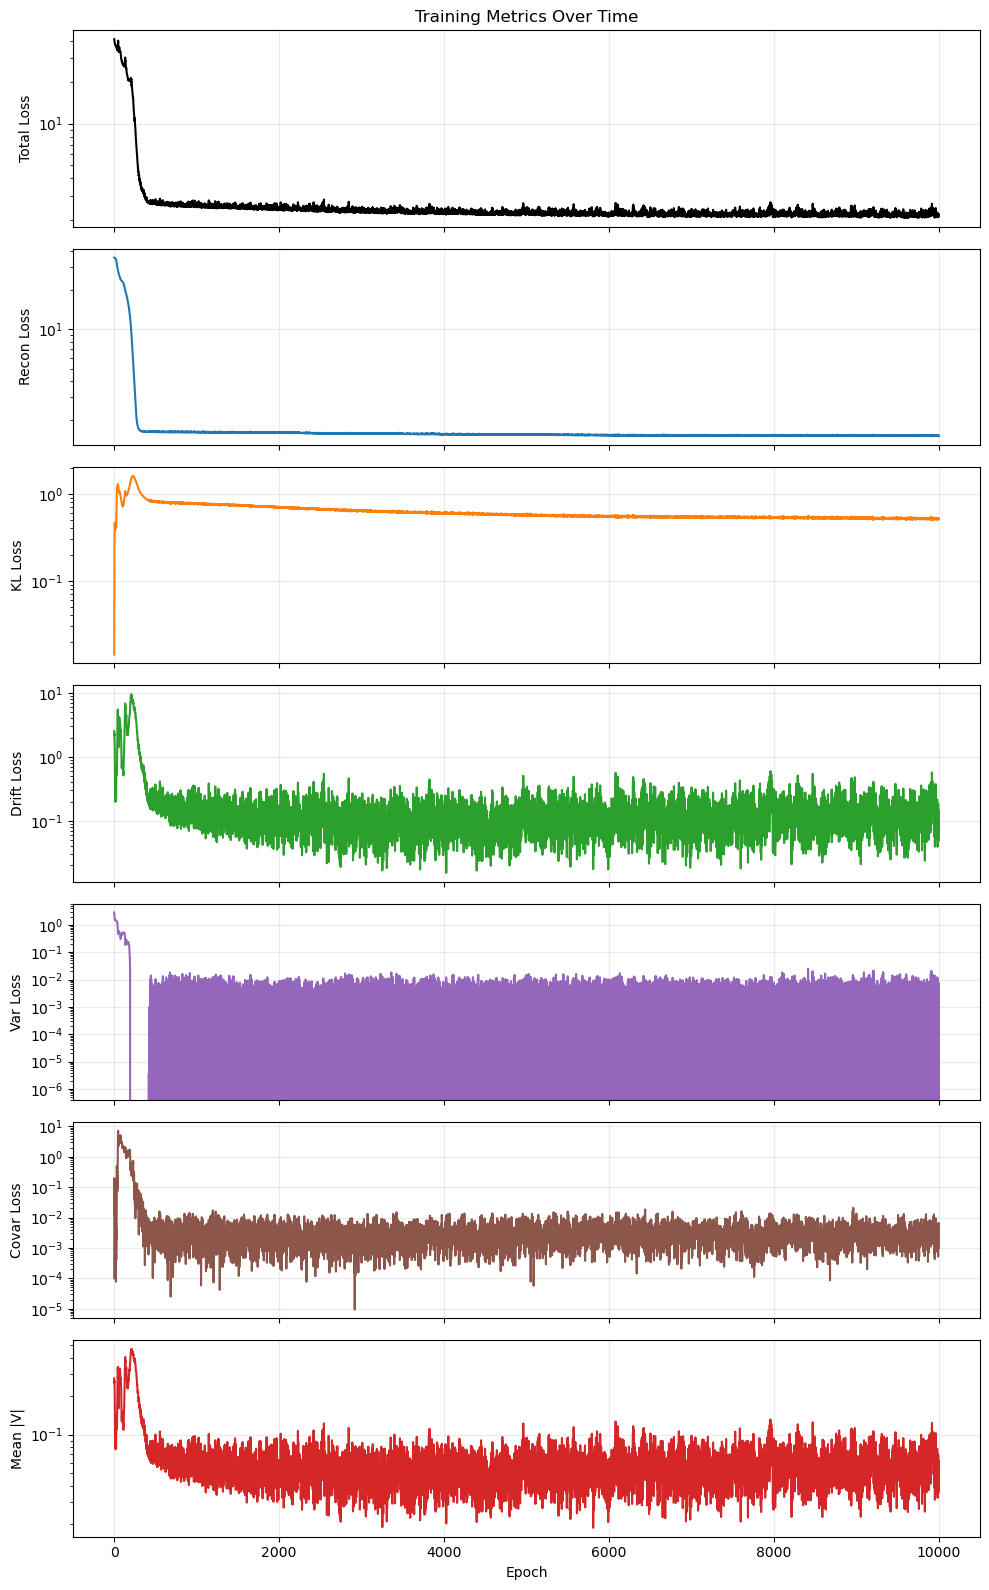

In [9]:
fig, axes = plot_training_metrics(
    losses,
    recon_losses,
    kl_losses,
    drift_losses,
    var_losses,
    covar_losses,
    average_V,
)

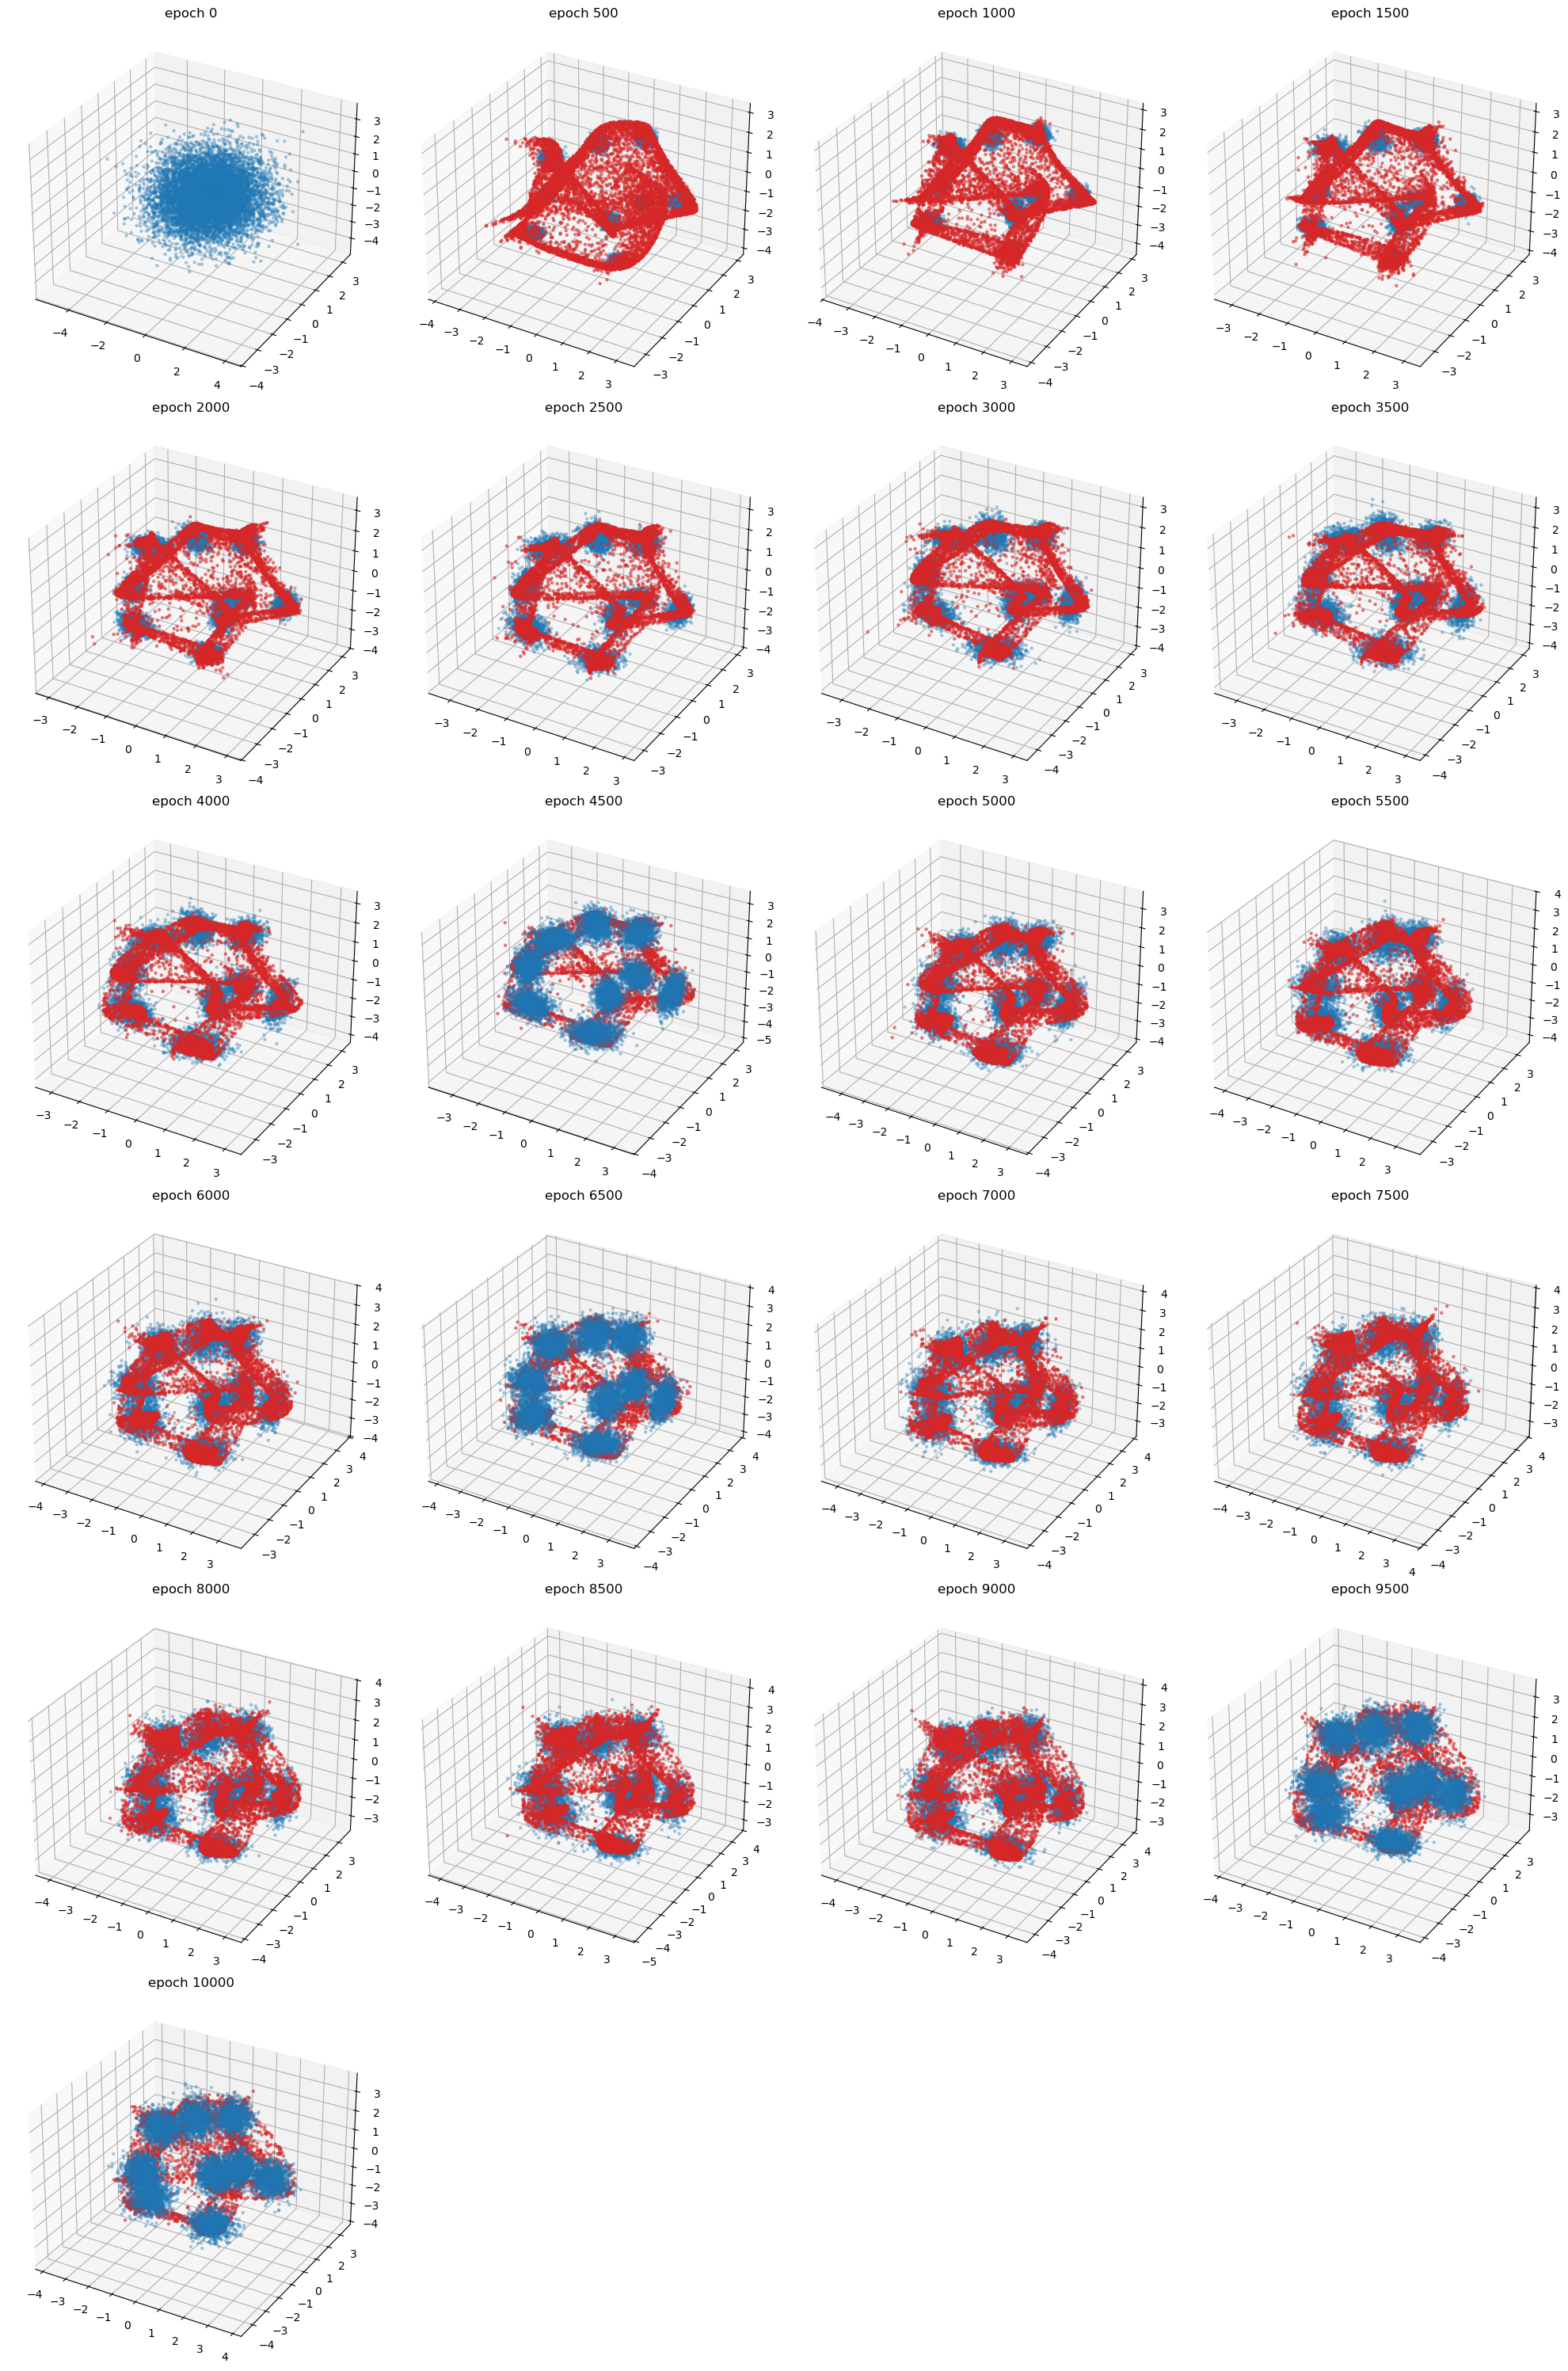

In [10]:
n_snaps = len(evolution)
n_cols = 4
n_rows = (n_snaps + n_cols - 1) // n_cols

fig = plt.figure(figsize=(5 * n_cols, 5 * n_rows))
for i, snap in enumerate(evolution):
    ax = fig.add_subplot(n_rows, n_cols, i + 1, projection='3d')
    ax.scatter(snap['pos'][:,0], snap['pos'][:,1], snap['pos'][:,2],
               c='tab:blue', alpha=0.3, s=5)
    ax.scatter(snap['neg'][:,0], snap['neg'][:,1], snap['neg'][:,2],
               c='tab:red', alpha=0.5, s=5)
    ax.set_title(f"epoch {snap.get('epoch', i)}")

plt.tight_layout()
plt.show()

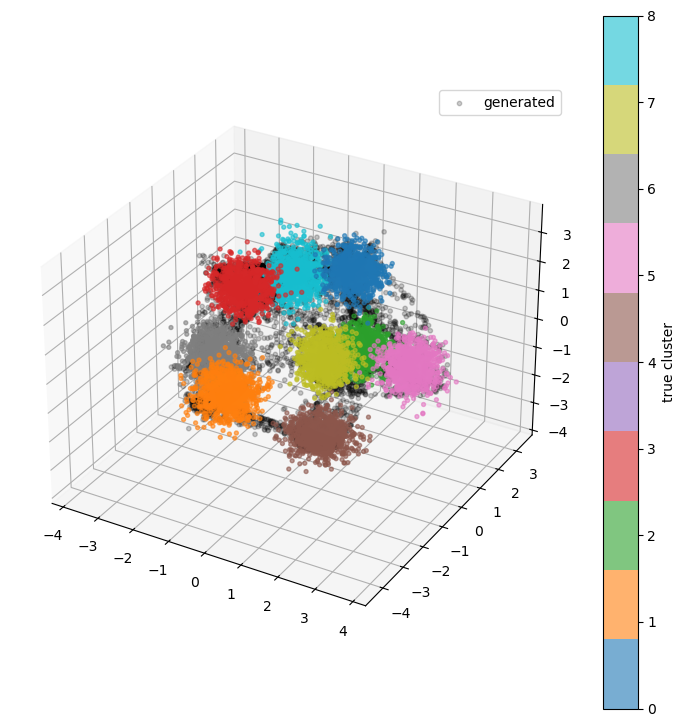

In [18]:
fig = plt.figure(figsize=(9, 9))
pos, neg = snap["pos"], snap["neg"]
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(pos[:,0], pos[:,1], pos[:,2], c=y, cmap='tab10', s=8, alpha=0.6)
ax.scatter(neg[:,0], neg[:,1], neg[:,2], c='black', s=10, alpha=0.2, label='generated')
plt.colorbar(sc, label='true cluster')
ax.legend()
plt.show()

In [12]:
generated_nn, q99 = latent_support_report(pos, neg)
bridge_mask = generated_nn > q99
bridge_points = neg[bridge_mask.cpu().numpy()]

print(f"Likely bridge / unsupported points: {bridge_mask.float().mean():.1%}")

Real nearest-neighbor distance, median: 0.0014
Generated nearest-real distance, median: 0.0782
Generated within real 95% support: 84.8%
Generated within real 99% support: 91.1%
Likely bridge / unsupported points: 8.9%


In [13]:
f_trained.eval()
with torch.no_grad():
    mu, logvar, y_pos_latent = f_trained.get_latent(truth)
    y_pos_recon = f_trained.decoder(y_pos_latent)

recon_per_sample = ((y_pos_recon - truth) ** 2).mean(dim=1)
y_t = torch.from_numpy(y).to(recon_per_sample.device)

for c in range(9):
    print(c, recon_per_sample[y_t == c].mean().item())

0 1.5281676054000854
1 1.5152428150177002
2 1.5254971981048584
3 1.5168745517730713
4 1.5274404287338257
5 1.5087796449661255
6 1.5269209146499634
7 1.5356009006500244
8 1.538936972618103


In [ ]:
def total_loss(
    y_pos_recon, y_pos, y_pos_mu, y_pos_logvar,
    y_neg_latent, y_pos_latent, temp,
    landmarks, K_uu_inv_sqrt, Ap, bp,
    lambda_kl=0.01,
    lambda_drift=1.0,
    lambda_var=0.1,
    lambda_cov=0.1
):
    L_recon = recon_loss(y_pos_recon, y_pos)
    L_kl = kl_loss(y_pos_mu, y_pos_logvar)

    # Original generator-side drift
    L_drift_neg, V_neg = drift_loss(
        y_neg_latent, landmarks,
        K_uu_inv_sqrt, Ap, bp, temp
    )

    # Added encoder-side drift
    L_drift_pos, V_pos = drift_loss(
        y_pos_latent, landmarks,
        K_uu_inv_sqrt, Ap, bp, temp
    )

    L_drift = L_drift_neg + L_drift_pos

    L_var = (
        variance_loss(y_pos_mu)
        + variance_loss(y_neg_latent)
    )

    L_cov = (
        covariance_loss(y_pos_mu)
        + covariance_loss(y_neg_latent)
    )

    total = (
        L_recon
        + lambda_kl * L_kl
        + lambda_drift * L_drift
        + lambda_var * L_var
        + lambda_cov * L_cov
    )

    loss_items = {
        "recon": L_recon.detach(),
        "kl": L_kl.detach(),
        "drift": L_drift.detach(),
        "drift_negative": L_drift_neg.detach(),
        "drift_positive": L_drift_pos.detach(),
        "V": V_neg.detach(),
        "var": L_var.detach(),
        "covar": L_cov.detach(),
    }

    return total, loss_items